# Run on google colab only

This notebook is optimized for Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ln -sf '/content/drive/MyDrive/piano-chords/svm_gridsearch' '/content/svm_gridsearch'

Mounted at /content/drive


# Define constants

In [5]:
from scipy.stats import loguniform

FEATURES_PATH = "./svm_gridsearch/test-all.npz"
MODEL_ZIP_PATH = "./svm_gridsearch/svm_models.zip"
MODEL_SAVE_PATH = "./models"
RANDOM_STATE = 42

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
SVM_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, 'model.pkl')
SVM_SCALER_PATH = os.path.join(MODEL_SAVE_PATH, 'scaler.pkl')
SVM_ENCODER_PATH = os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl')

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
import random
import numpy as np

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [6]:
import shutil
import zipfile
import os

local_zip = os.path.basename(MODEL_ZIP_PATH)
shutil.copy(MODEL_ZIP_PATH, local_zip)

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall('.')

print(f"Extracted {local_zip} to {MODEL_SAVE_PATH}")

Extracted svm_models.zip to ./models


# Test Noisy

## Load Model & Noisy Features

In [7]:
import joblib

svm_model = joblib.load(SVM_MODEL_PATH)
svm_scaler = joblib.load(SVM_SCALER_PATH)
svm_label_encoder = joblib.load(SVM_ENCODER_PATH)

with np.load(FEATURES_PATH) as data:
    features = data['features']
    labels = data['labels']

print(f"SVM model loaded from {MODEL_SAVE_PATH}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


## Test SVM Model

SVM Test Accuracy on Evaluation Dataset: 0.293056

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.20      0.33        40
     A#_major_4       0.00      0.00      0.00        40
     A#_minor_4       0.00      0.00      0.00        40
 A_diminished_4       0.00      0.00      0.00        40
      A_major_4       0.00      0.00      0.00        40
      A_minor_4       0.18      0.05      0.08        40
 B_diminished_4       0.00      0.00      0.00        40
      B_major_4       0.00      0.00      0.00        40
      B_minor_4       0.00      0.00      0.00        40
C#_diminished_4       0.62      0.75      0.68        40
     C#_major_4       1.00      0.15      0.26        40
     C#_minor_4       1.00      0.50      0.67        40
 C_diminished_4       0.04      1.00      0.08        40
      C_major_4       1.00      0.50      0.67        40
      C_minor_4       1.00      0.50      0.67        40
D#_diminishe

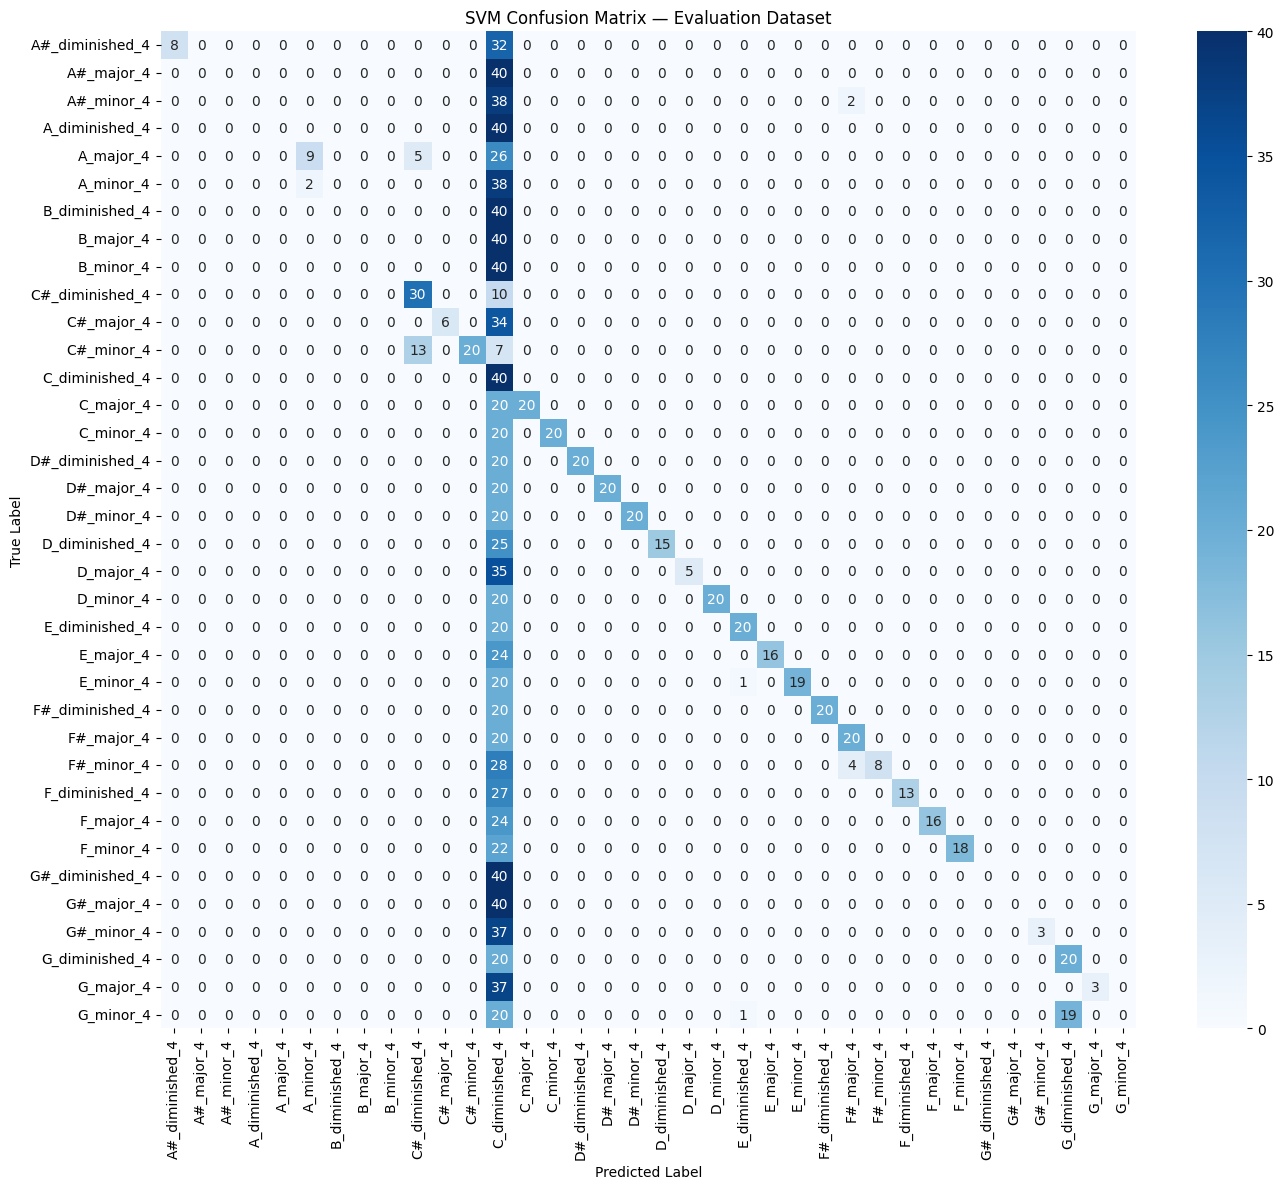

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten and scale features the same way as training data
features_flat   = features.reshape(features.shape[0], -1)
features_scaled = svm_scaler.transform(features_flat)

# Encode labels using the loaded label encoder
svm_encoded = svm_label_encoder.transform(labels)

# Predict
y_pred = svm_model.predict(features_scaled)

# Accuracy & report
svm_accuracy = accuracy_score(svm_encoded, y_pred)
print(f"SVM Test Accuracy on Evaluation Dataset: {svm_accuracy:.6f}")

svm_class_labels = svm_label_encoder.classes_
report_svm = classification_report(svm_encoded, y_pred, target_names=svm_class_labels, zero_division=0)
print("\nClassification Report:\n", report_svm)

# Confusion matrix
cm_svm = confusion_matrix(svm_encoded, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Evaluation Dataset')
plt.tight_layout()
plt.show()